# 01 — Exploratory Data Analysis
### Thai Character Recognition (72 คลาส)

เป้าหมายของ notebook นี้:
1. ยืนยันตัวเลขจริงของ dataset (จำนวนภาพ/คลาส, imbalance ratio)
2. หา**ปัญหาที่มองไม่เห็นจากตัวเลข** — ขนาดภาพไม่เท่ากัน, polarity สลับ, ภาพเสีย
3. พิสูจน์ด้วยภาพว่าคลาสไหน**หน้าตาคล้ายกัน**จนโมเดลน่าจะสับสน
4. ตรวจว่า augmentation ที่ตั้งไว้ยัง "อ่านออกเป็นตัวอักษรเดิม" อยู่
5. Export กราฟทั้งหมดไปใส่สไลด์

> ทุกกราฟจะถูกบันทึกที่ `outputs/figures/eda_*.png`

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, warnings
from pathlib import Path

# ให้ working directory เป็น project root เสมอ (path ใน config เป็น relative)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from src.config import load_config
from src.class_map import ClassMap, SIMILAR_GROUPS, readable_name
from src.dataset import read_image
from src.utils import list_images, ensure_dir, setup_thai_font, seed_everything

seed_everything(42)
sns.set_style("whitegrid")        # ← ย้าย sns มาก่อน
font = setup_thai_font()          # ← set font หลัง sns
plt.rcParams["figure.dpi"] = 110

cfg = load_config("configs/base.yaml")
RAW_DIR = Path(cfg.get_path("paths.raw_dir"))
FIG_DIR = Path(cfg.get_path("paths.figure_dir")); ensure_dir(FIG_DIR)

print(f"root      : {ROOT}")
print(f"thai font : {font}")
print(f"raw dir   : {RAW_DIR}  (exists={RAW_DIR.exists()})")

root      : c:\Users\aungl\Downloads\thai-char-cnn
thai font : Leelawadee UI
raw dir   : data\raw  (exists=True)


## 1. โหลด Class Map และสถิติพื้นฐาน
Folder ID คือรหัส **TIS-620** ของอักษรไทย (161 = 0xA1 = ก) จึง decode กลับเป็นตัวอักษรได้ตรง ๆ

In [2]:
cm = ClassMap.from_raw_dir(RAW_DIR, strict=False)
counts = np.array(cm.counts_by_label())
total = counts.sum()

stats = pd.DataFrame({
    "label": range(cm.num_classes),
    "folder_id": [cm.label_to_folder[i] for i in range(cm.num_classes)],
    "class": cm.class_names,
    "readable": cm.readable_names,
    "count": counts,
})
stats["percent"] = stats["count"] / total * 100
stats["tier"] = pd.cut(stats["count"], [-1, 19, 49, 199, 10**9],
                       labels=["<20", "20-49", "50-199", ">=200"])
stats = stats.sort_values("count", ascending=False).reset_index(drop=True)

print(f"คลาส        : {cm.num_classes}")
print(f"ภาพทั้งหมด  : {total:,}")
print(f"เฉลี่ย/คลาส : {total/cm.num_classes:,.0f}   มัธยฐาน: {np.median(counts):,.0f}")
print(f"มากสุด      : {stats.iloc[0]['class']} = {stats.iloc[0]['count']:,}")
print(f"น้อยสุด     : {stats.iloc[-1]['class']} = {stats.iloc[-1]['count']:,}")
print(f"Imbalance   : {counts.max()/max(counts.min(),1):,.0f} : 1")
stats.head(10)

คลาส        : 72
ภาพทั้งหมด  : 62,707
เฉลี่ย/คลาส : 871   มัธยฐาน: 221
มากสุด      : า = 5,025
น้อยสุด     : ฑ = 1
Imbalance   : 5,025 : 1


,label,folder_id,class,readable,count,percent,tier
0,43,210,า,-า (สระอา),5025,8.013459,>=200
1,20,185,น,น,4863,7.755115,>=200
2,30,195,ร,ร,4663,7.436171,>=200
3,42,209,ั,-ั (ไม้หันอากาศ),4120,6.570239,>=200
4,28,193,ม,ม,3306,5.272139,>=200
5,39,205,อ,อ,3272,5.217918,>=200
6,55,229,ๅ,ๅ (ลากข้าง),2310,3.683799,>=200
7,29,194,ย,ย,2197,3.503596,>=200
8,32,197,ล,ล,2187,3.487649,>=200
9,15,180,ด,ด,2025,3.229305,>=200


In [3]:
# ตารางสรุปตามช่วง — ตัวเลขชุดนี้เอาไปใส่สไลด์ได้เลย
tier = (stats.groupby("tier", observed=True)
             .agg(n_classes=("count", "size"), n_images=("count", "sum")))
tier["pct_of_classes"] = tier["n_classes"] / cm.num_classes * 100
tier["pct_of_images"]  = tier["n_images"] / total * 100
display(tier.style.format({"n_images": "{:,}", "pct_of_classes": "{:.1f}%",
                           "pct_of_images": "{:.1f}%"}))

lt50 = stats[stats["count"] < 50]
print(f"\n⚠️ {len(lt50)} คลาสมีภาพ < 50  รวมกัน {lt50['count'].sum():,} ภาพ "
      f"({lt50['count'].sum()/total*100:.2f}% ของ dataset)")
print("  →", " ".join(lt50["class"].tolist()))

,n_classes,n_images,pct_of_classes,pct_of_images
tier,,,,
<20,11,106,15.3%,0.2%
20-49,12,434,16.7%,0.7%
50-199,12,"1,391",16.7%,2.2%
>=200,37,"60,776",51.4%,96.9%



⚠️ 23 คลาสมีภาพ < 50  รวมกัน 540 ภาพ (0.86% ของ dataset)
  → ๊ ฒ ิ ๑ ฉ ฝ ๒ ฏ ๘ ๓ แ ฯ ๕ ๔ ๙ ึ ฤ ๖ ฮ ๗ ฬ ฃ ฑ


## 2. การกระจายตัวของข้อมูล
ใช้ log scale เพราะ ratio สูงเกินกว่าจะพล็อตแบบ linear ได้

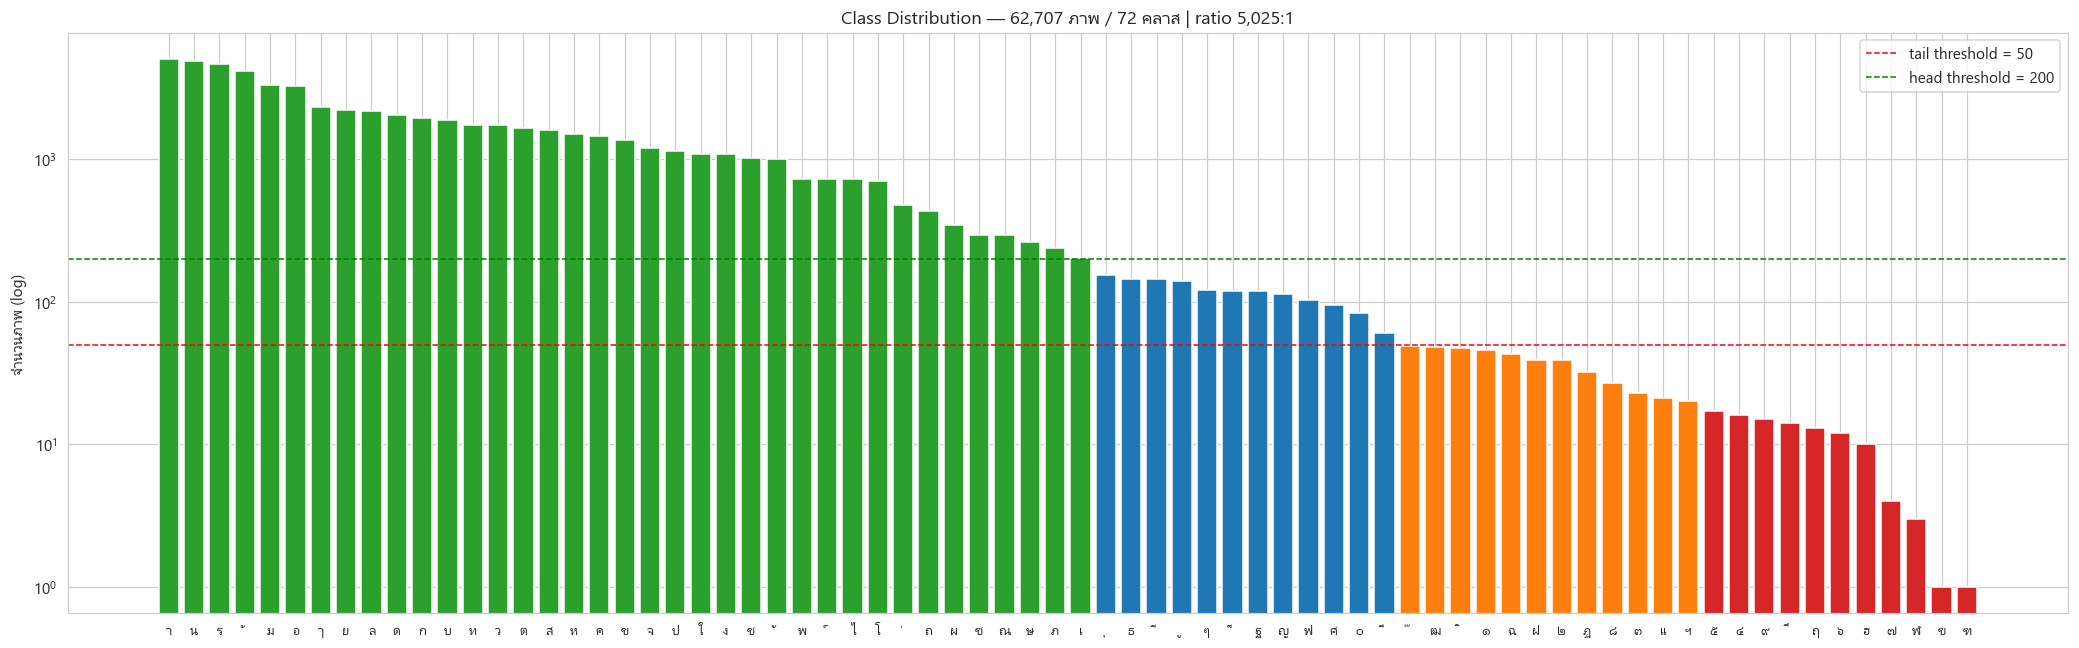

In [4]:
fig, ax = plt.subplots(figsize=(19, 6))
palette = {"<20": "#d62728", "20-49": "#ff7f0e", "50-199": "#1f77b4", ">=200": "#2ca02c"}
ax.bar(range(len(stats)), stats["count"], color=[palette[str(t)] for t in stats["tier"]])
ax.set_yscale("log")
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(stats["class"], fontsize=9)
ax.axhline(50, ls="--", c="red", lw=1, label="tail threshold = 50")
ax.axhline(200, ls="--", c="green", lw=1, label="head threshold = 200")
ax.set_ylabel("จำนวนภาพ (log)")
ax.set_title(f"Class Distribution — {total:,} ภาพ / {cm.num_classes} คลาส "
             f"| ratio {counts.max():,}:{counts.min()}")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR/"eda_01_distribution.png", dpi=150); plt.show()

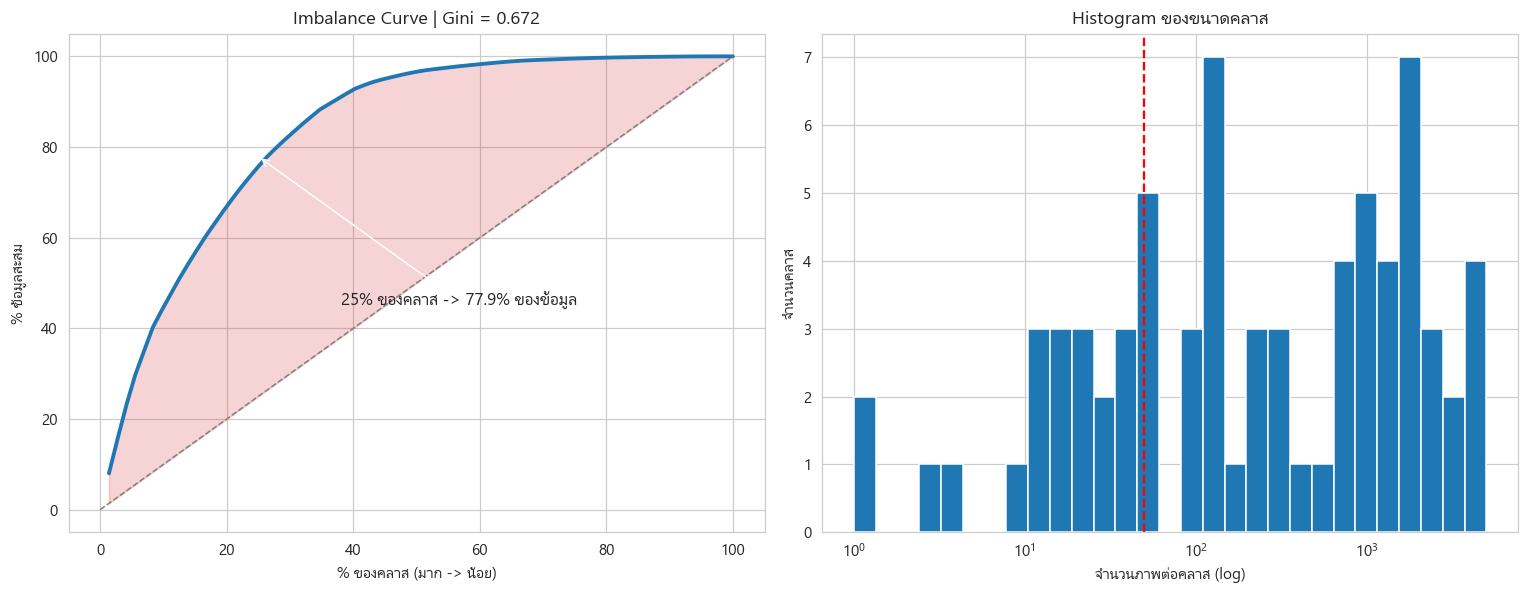

Gini coefficient = 0.672  (0 = สมดุลสมบูรณ์, 1 = ไม่สมดุลสุดขีด)


In [17]:
# Cumulative curve + Gini — ตัวเลข Gini ใส่สไลด์ได้ ดูโปรมาก
srt = np.sort(counts)
cum = np.cumsum(srt) / srt.sum()
n = len(srt)
gini = (2*np.sum((np.arange(1, n+1))*srt)) / (n*srt.sum()) - (n+1)/n

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

c = stats["count"].cumsum()/total*100
x = np.arange(1, len(stats)+1)/len(stats)*100
axes[0].plot(x, c, lw=2.5); axes[0].plot([0,100],[0,100],"--",c="gray",lw=1)
axes[0].fill_between(x, c, x, alpha=.2, color="#d62728")
i25 = int(len(stats)*.25)
axes[0].annotate(f"25% ของคลาส -> {c.iloc[i25]:.1f}% ของข้อมูล",
                 xy=(25, c.iloc[i25]), xytext=(38, 45),
                 arrowprops=dict(arrowstyle="->"), fontsize=11)
axes[0].set_xlabel("% ของคลาส (มาก -> น้อย)"); axes[0].set_ylabel("% ข้อมูลสะสม")
axes[0].set_title(f"Imbalance Curve | Gini = {gini:.3f}")

axes[1].hist(counts, bins=np.logspace(0, np.log10(counts.max()+1), 30),
             color="#1f77b4", edgecolor="white")
axes[1].set_xscale("log"); axes[1].set_xlabel("จำนวนภาพต่อคลาส (log)")
axes[1].set_ylabel("จำนวนคลาส"); axes[1].set_title("Histogram ของขนาดคลาส")
axes[1].axvline(50, ls="--", c="red")

fig.tight_layout(); fig.savefig(FIG_DIR/"eda_02_imbalance.png", dpi=150); plt.show()
print(f"Gini coefficient = {gini:.3f}  (0 = สมดุลสมบูรณ์, 1 = ไม่สมดุลสุดขีด)")

## 3. คุณสมบัติของภาพ — ปัญหาที่ตัวเลขไม่บอก
สุ่มตรวจภาพจริงเพื่อหา:
- **ขนาด/aspect ratio ไม่เท่ากัน** → ยืนยันว่าต้อง pad-to-square ไม่ใช่ resize ตรง ๆ
- **Polarity สลับ** (บางภาพขาวบนดำ) → ยืนยันว่าต้องมี AutoInvert
- **Ink ratio** สัดส่วนพิกเซลหมึก → คลาสสระ/วรรณยุกต์จะต่ำมาก
- **ภาพเสีย / ภาพว่าง**

In [6]:
SAMPLE_PER_CLASS = 25   # ลดลงถ้าอยากเร็ว, ใส่ None เพื่อสแกนทั้งหมด

rows, broken = [], []
for label in tqdm(range(cm.num_classes), desc="scanning images"):
    folder = cm.label_to_folder[label]
    files = list_images(RAW_DIR/str(folder))
    if SAMPLE_PER_CLASS:
        files = files[:SAMPLE_PER_CLASS]
    for f in files:
        try:
            img = read_image(f)
        except Exception as e:
            broken.append((str(f), str(e))); continue
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        h, w = g.shape
        k = max(2, min(h, w)//12)
        corner = np.concatenate([g[:k,:k].ravel(), g[:k,-k:].ravel(),
                                 g[-k:,:k].ravel(), g[-k:,-k:].ravel()]).mean()
        dark_bg = corner < 110
        ink = (g > 128).mean() if dark_bg else (g < 128).mean()
        rows.append({"label": label, "class": cm.label_to_char[label],
                     "w": w, "h": h, "aspect": w/h, "ink_ratio": ink,
                     "dark_bg": dark_bg, "std": float(g.std()),
                     "path": str(f)})

props = pd.DataFrame(rows)
print(f"สแกน {len(props):,} ภาพ | ภาพเสีย {len(broken)} ไฟล์")
print(f"ขนาด  : {props['w'].min()}x{props['h'].min()} ถึง {props['w'].max()}x{props['h'].max()}")
print(f"aspect: {props['aspect'].min():.2f} – {props['aspect'].max():.2f} "
      f"(mean {props['aspect'].mean():.2f})")
print(f"พื้นหลังดำ (ต้อง invert): {props['dark_bg'].sum():,} ภาพ "
      f"({props['dark_bg'].mean()*100:.1f}%)")
print(f"ภาพเกือบว่าง (std<5)    : {(props['std']<5).sum()} ภาพ")
if broken:
    display(pd.DataFrame(broken, columns=["path","error"]).head())

scanning images:   0%|          | 0/72 [00:00<?, ?it/s]

สแกน 1,620 ภาพ | ภาพเสีย 0 ไฟล์
ขนาด  : 3x6 ถึง 38x47
aspect: 0.28 – 2.33 (mean 0.85)
พื้นหลังดำ (ต้อง invert): 156 ภาพ (9.6%)
ภาพเกือบว่าง (std<5)    : 3 ภาพ


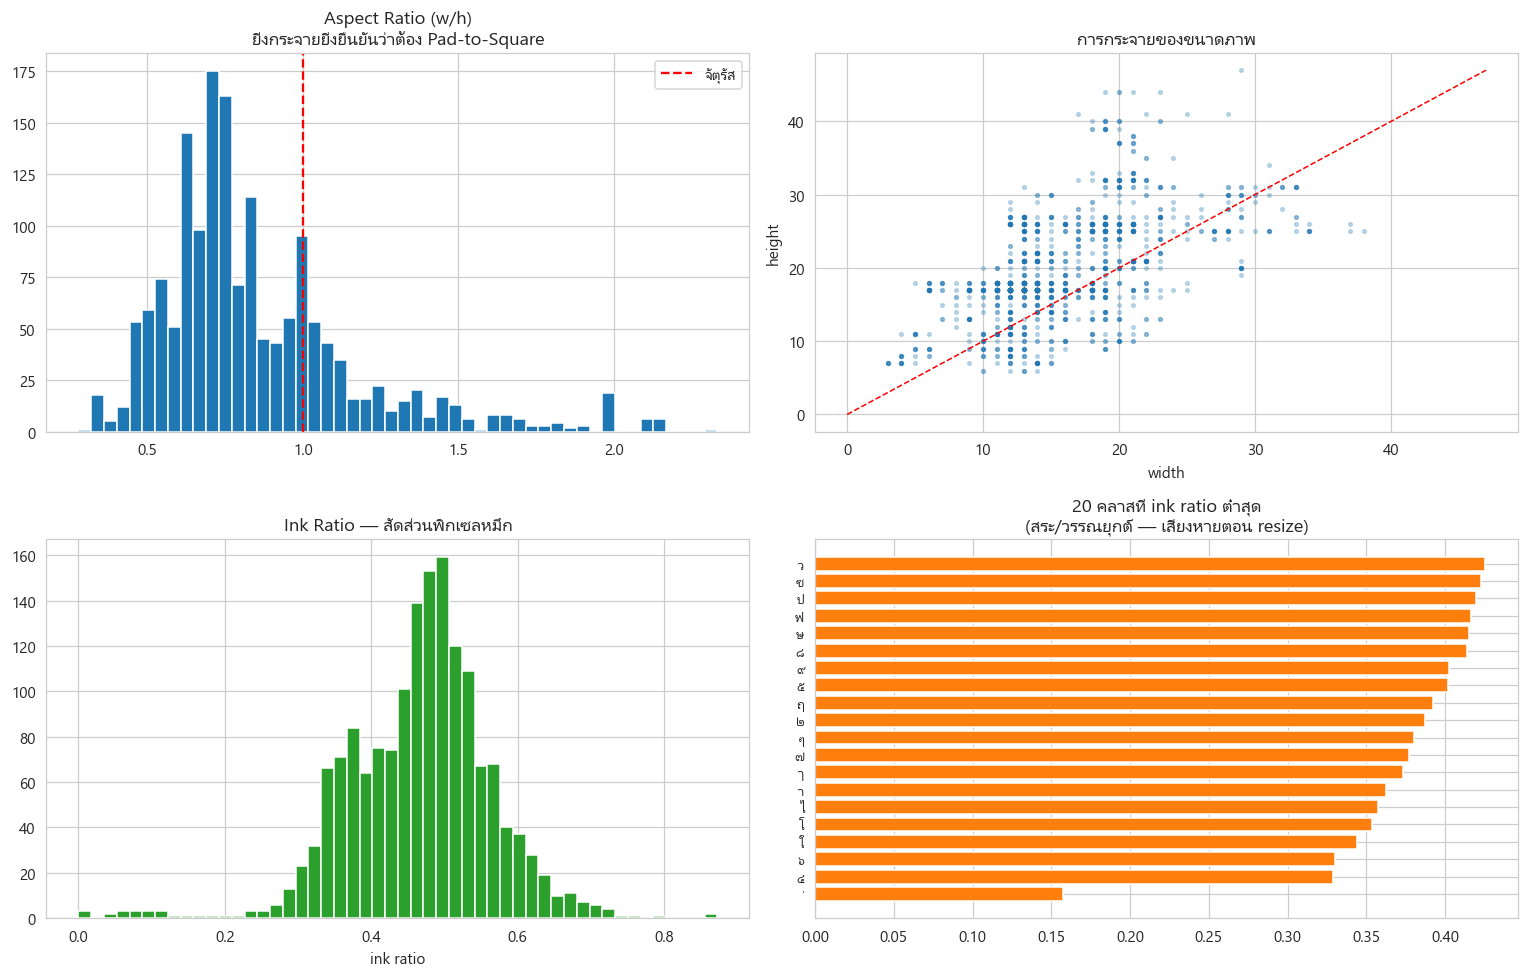

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(props["aspect"], bins=50, color="#1f77b4", edgecolor="white")
axes[0,0].axvline(1.0, ls="--", c="red", label="จัตุรัส")
axes[0,0].set_title("Aspect Ratio (w/h)\nยิ่งกระจายยิ่งยืนยันว่าต้อง Pad-to-Square")
axes[0,0].legend()

axes[0,1].scatter(props["w"], props["h"], s=6, alpha=.25)
lim = max(props["w"].max(), props["h"].max())
axes[0,1].plot([0,lim],[0,lim],"--",c="red",lw=1)
axes[0,1].set_xlabel("width"); axes[0,1].set_ylabel("height")
axes[0,1].set_title("การกระจายของขนาดภาพ")

axes[1,0].hist(props["ink_ratio"], bins=50, color="#2ca02c", edgecolor="white")
axes[1,0].set_title("Ink Ratio — สัดส่วนพิกเซลหมึก")
axes[1,0].set_xlabel("ink ratio")

ink_by_class = (props.groupby("class")["ink_ratio"].mean()
                     .sort_values().head(20))
axes[1,1].barh(range(len(ink_by_class)), ink_by_class.values, color="#ff7f0e")
axes[1,1].set_yticks(range(len(ink_by_class)))
axes[1,1].set_yticklabels(ink_by_class.index, fontsize=9)
axes[1,1].set_title("20 คลาสที่ ink ratio ต่ำสุด\n(สระ/วรรณยุกต์ — เสี่ยงหายตอน resize)")

fig.tight_layout(); fig.savefig(FIG_DIR/"eda_03_image_properties.png", dpi=150); plt.show()

## 4. Visual Similarity — ปัญหาที่สองของโปรเจกต์
ดูภาพจริงของกลุ่มที่คล้ายกัน แล้วถามตัวเองว่า *"ถ้าเราเป็นโมเดล เราจะแยกออกไหม?"*

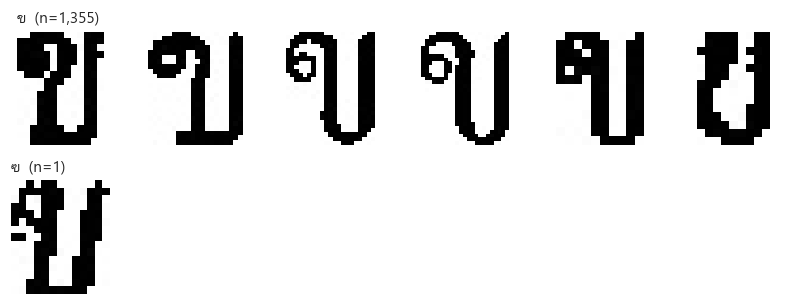

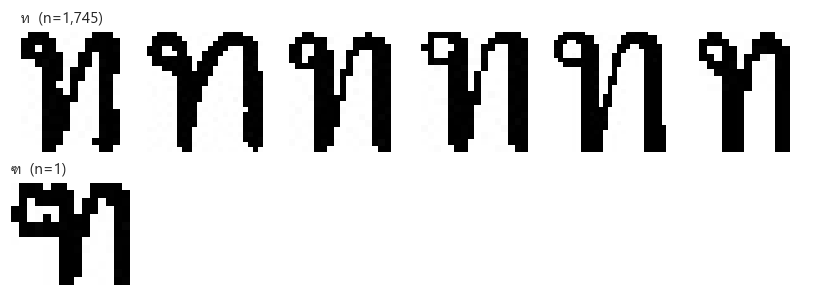

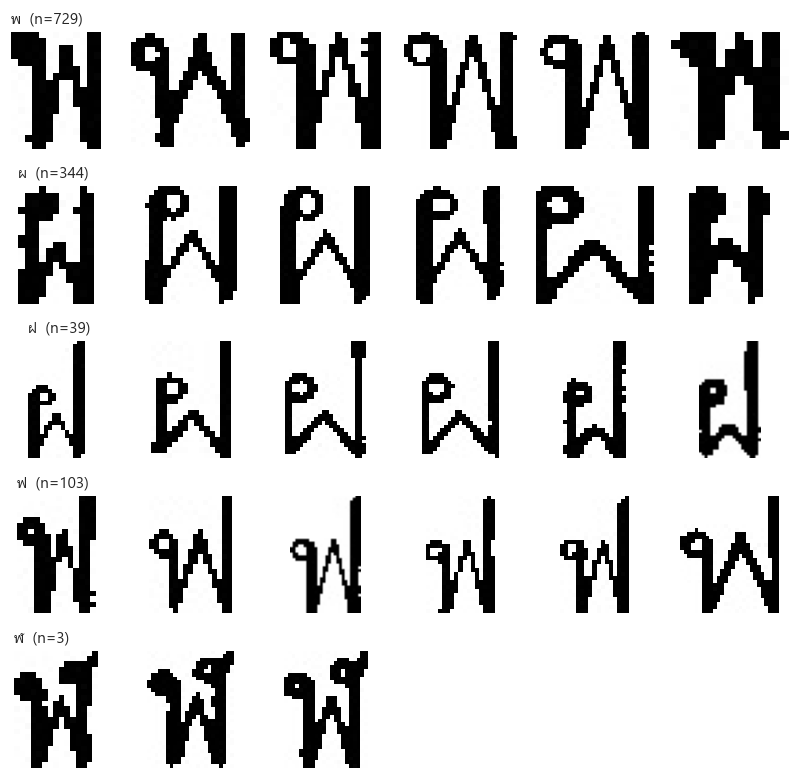

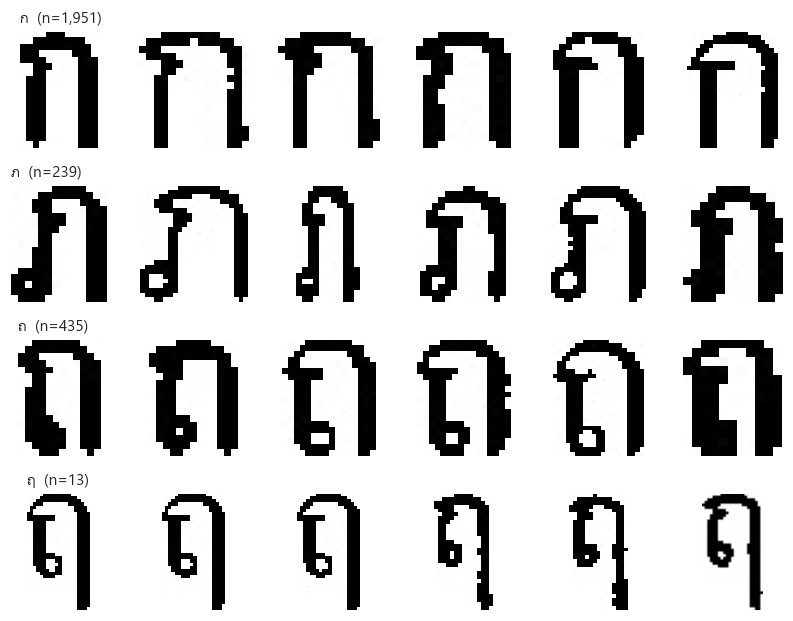

In [8]:
def show_group(group, n_per=6, figsize_scale=1.25):
    group = [c for c in group if c in cm.char_to_label]
    fig, axes = plt.subplots(len(group), n_per,
                             figsize=(n_per*figsize_scale, len(group)*figsize_scale*1.15))
    axes = np.atleast_2d(axes)
    for r, ch in enumerate(group):
        label = cm.char_to_label[ch]
        folder = cm.label_to_folder[label]
        files = list_images(RAW_DIR/str(folder))
        pick = files[:n_per] if len(files) <= n_per else \
               [files[i] for i in np.linspace(0, len(files)-1, n_per).astype(int)]
        for c in range(n_per):
            ax = axes[r, c]; ax.axis("off")
            if c < len(pick):
                ax.imshow(read_image(pick[c]), cmap="gray")
            if c == 0:
                ax.set_ylabel(ch)
                ax.set_title(f"{readable_name(ch)}  (n={len(files):,})",
                             fontsize=10, loc="left")
    fig.tight_layout(); return fig

for g in [["ข","ฃ"], ["ท","ฑ"], ["พ","ผ","ฝ","ฟ","ฬ"], ["ก","ภ","ถ","ฤ"]]:
    f = show_group(g); plt.show()

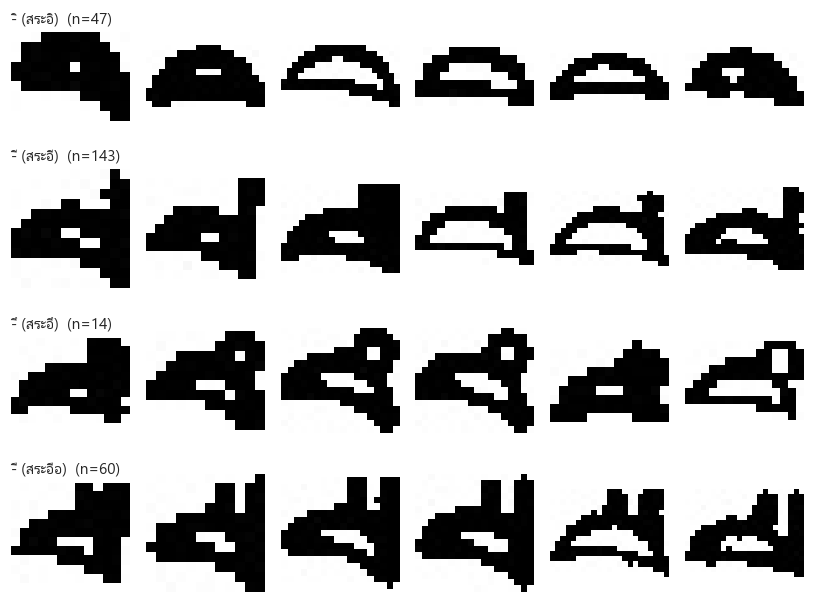

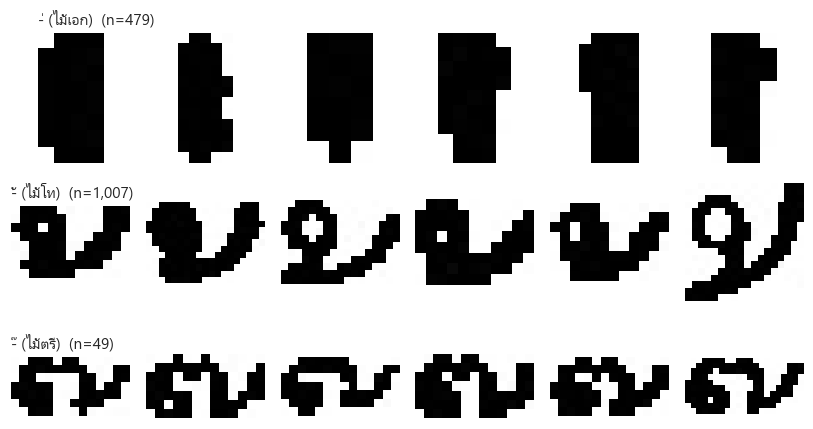

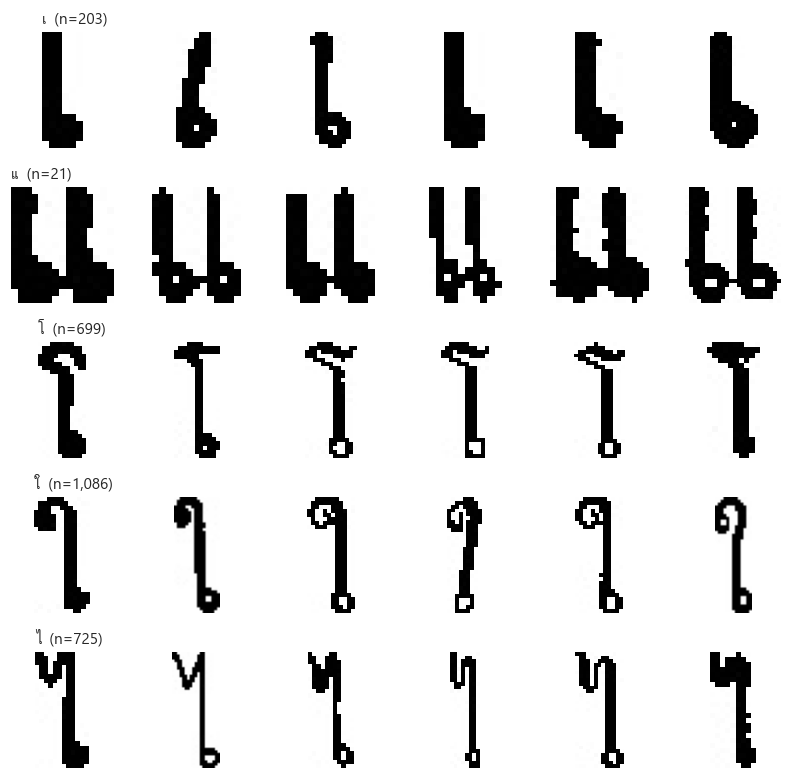

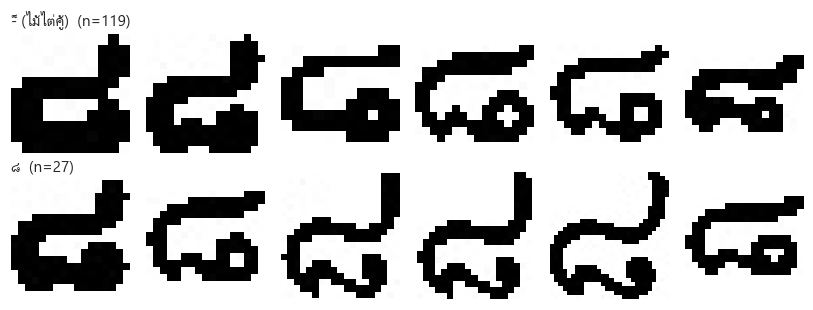

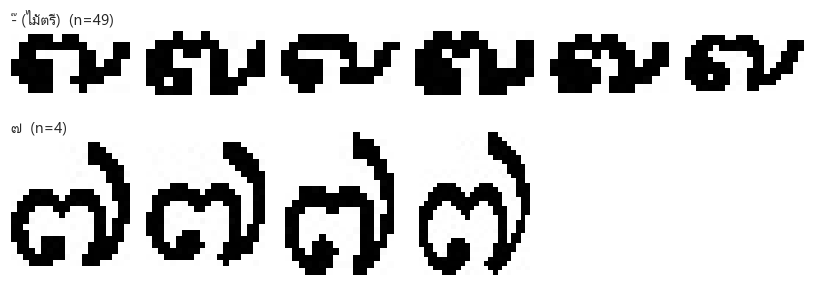

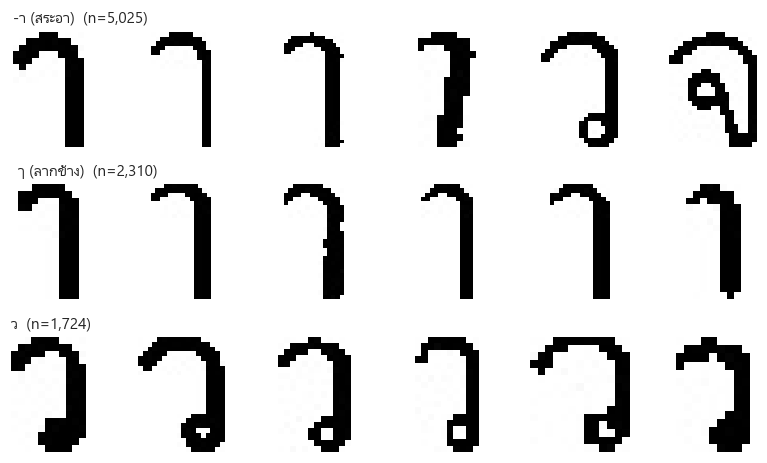

In [9]:
# กลุ่มสระ/วรรณยุกต์ — ต่างกันแค่ไม่กี่พิกเซล
for g in [["ิ","ี","ึ","ื"], ["่","้","๊"], ["เ","แ","โ","ใ","ไ"], ["็", "๘"], ["๊","๗"],["า", "ๅ", "ว"]]:
    f = show_group(g); plt.show()


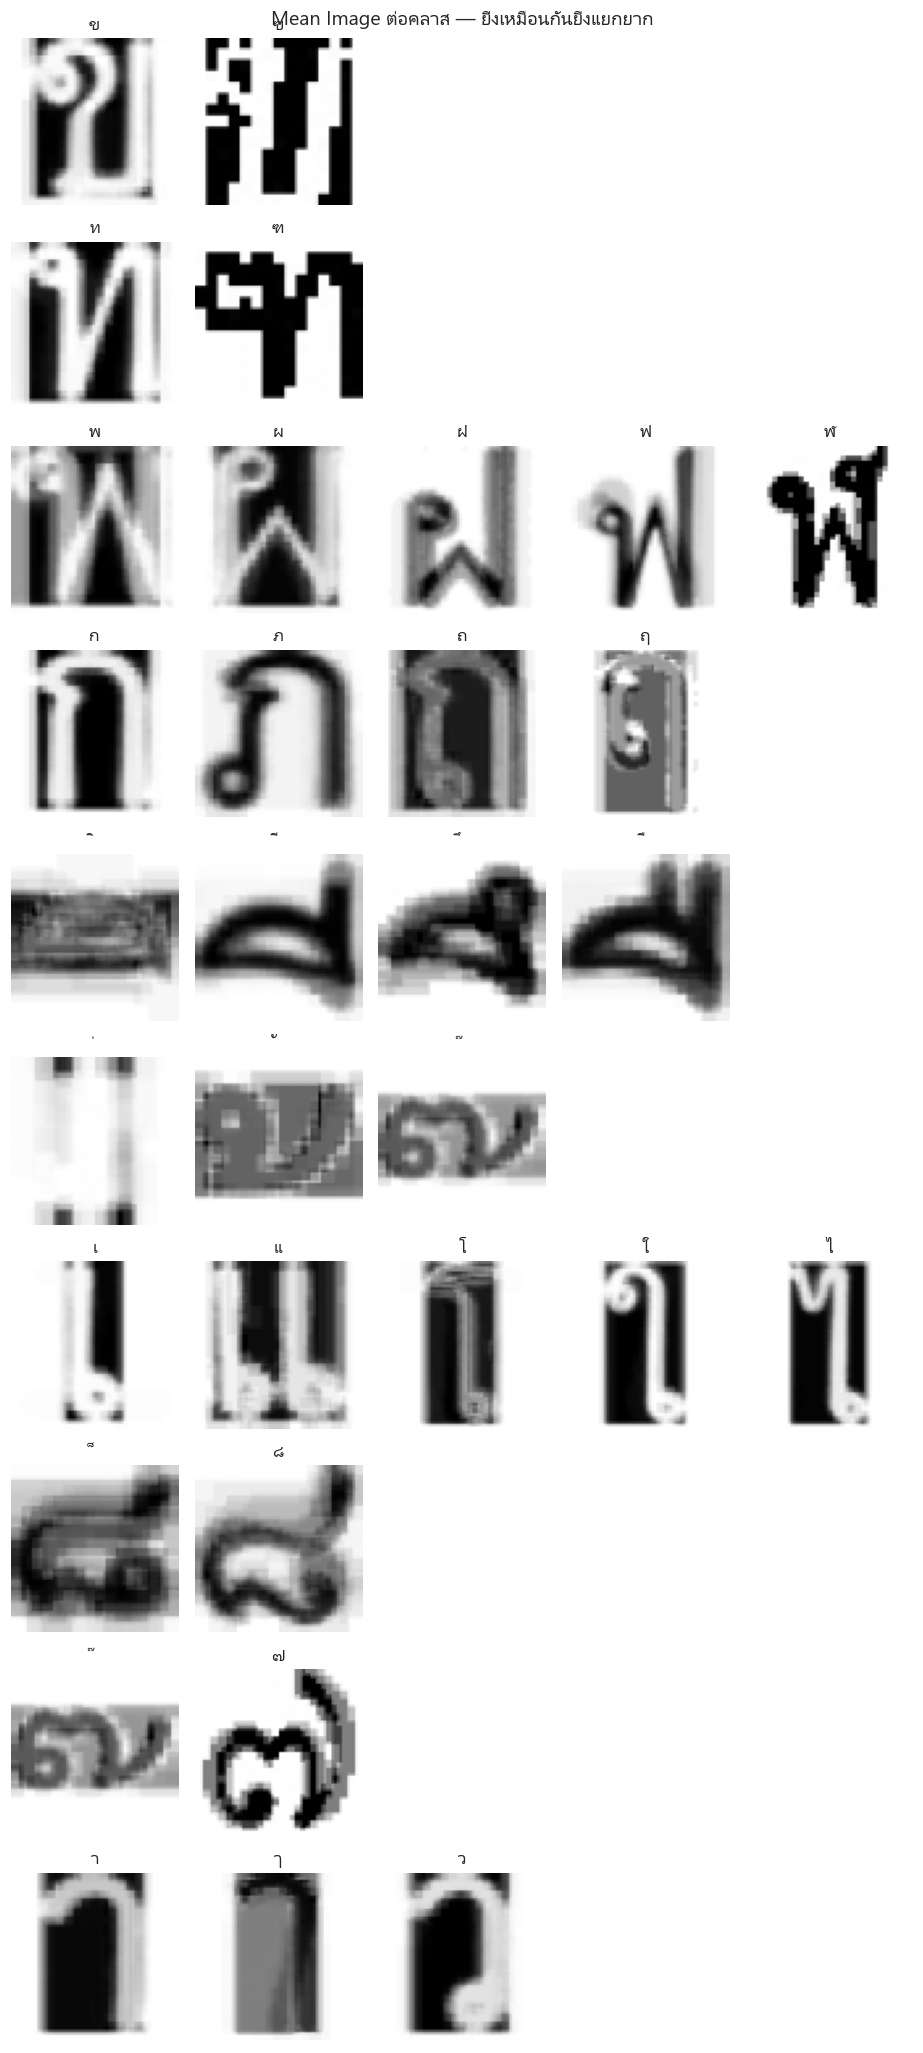

In [10]:
# Mean image ต่อคลาส — เห็น "ลายเซ็นเฉลี่ย" ของแต่ละตัวอักษรได้ชัดมาก
from src.transforms import PadToSquare
pad = PadToSquare(pad_value=255)

def mean_image(label, size=64, max_n=120):
    folder = cm.label_to_folder[label]
    files = list_images(RAW_DIR/str(folder))[:max_n]
    acc, k = np.zeros((size, size), np.float64), 0
    for f in files:
        try:
            g = cv2.cvtColor(read_image(f), cv2.COLOR_RGB2GRAY)
        except Exception:
            continue
        corner = np.concatenate([g[:5,:5].ravel(), g[-5:,-5:].ravel()]).mean()
        if corner < 110: g = 255 - g
        g = pad(image=g)["image"]
        acc += cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA); k += 1
    return acc/max(k,1)

groups_to_show = [["ข","ฃ"], ["ท","ฑ"], ["พ","ผ","ฝ","ฟ","ฬ"], ["ก","ภ","ถ","ฤ"],
                  ["ิ","ี","ึ","ื"], ["่","้","๊"], ["เ","แ","โ","ใ","ไ"], ["็", "๘"], ["๊","๗"],["า", "ๅ", "ว"]]
maxlen = max(len(g) for g in groups_to_show)
fig, axes = plt.subplots(len(groups_to_show), maxlen,
                         figsize=(maxlen*1.7, len(groups_to_show)*1.9))
for a in axes.ravel(): a.axis("off")
for r, g in enumerate(groups_to_show):
    for c, ch in enumerate(g):
        if ch not in cm.char_to_label: continue
        axes[r, c].imshow(mean_image(cm.char_to_label[ch]), cmap="gray")
        axes[r, c].set_title(ch, fontsize=12)
fig.suptitle("Mean Image ต่อคลาส — ยิ่งเหมือนกันยิ่งแยกยาก", fontsize=13)
fig.tight_layout(); fig.savefig(FIG_DIR/"eda_04_mean_images.png", dpi=150); plt.show()

In [11]:
# วัด "ความเหมือน" เชิงตัวเลขด้วย cosine similarity ของ mean image
labels_all = list(range(cm.num_classes))
M = np.stack([mean_image(l, size=48, max_n=60).ravel() for l in tqdm(labels_all)])
M = M - M.mean(1, keepdims=True)
M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-8)
S = M @ M.T
np.fill_diagonal(S, -1)

pairs = [{"a": cm.label_to_char[i], "b": cm.label_to_char[j],
          "similarity": float(S[i, j]),
          "n_a": int(counts[i]), "n_b": int(counts[j])}
         for i in range(cm.num_classes) for j in range(i+1, cm.num_classes)]
sim_df = pd.DataFrame(pairs).sort_values("similarity", ascending=False).head(25)
sim_df["risk"] = sim_df["similarity"] * (1 - sim_df[["n_a","n_b"]].min(1)/counts.max())
print("25 คู่ที่หน้าตาใกล้กันที่สุด (วัดจาก mean image):")
display(sim_df.reset_index(drop=True).style.format({"similarity":"{:.3f}","risk":"{:.3f}"}))
sim_df.to_csv(FIG_DIR/"eda_similar_pairs.csv", index=False, encoding="utf-8-sig")

  0%|          | 0/72 [00:00<?, ?it/s]

25 คู่ที่หน้าตาใกล้กันที่สุด (วัดจาก mean image):


,a,b,similarity,n_a,n_b,risk
0,ท,ห,0.950,1745,1490,0.668
1,ด,ต,0.945,2025,1662,0.632
2,ใ,ไ,0.932,1086,725,0.798
3,ี,ื,0.920,143,60,0.909
4,ึ,ื,0.898,14,60,0.896
5,ร,ๆ,0.898,4663,121,0.877
6,ก,ถ,0.897,1951,435,0.819
7,ว,า,0.894,1724,5025,0.587
8,ค,ธ,0.890,1448,143,0.864
9,ด,ธ,0.885,2025,143,0.859


## 5. ตรวจ Augmentation Pipeline
ข้อสำคัญ: augmentation ที่แรงเกินไปจะทำให้ **ฃ กลายเป็น ข** ซึ่งแย่กว่าไม่ augment เลย
ต้องดูด้วยตาว่าทุกภาพยัง "อ่านออกเป็นตัวเดิม"

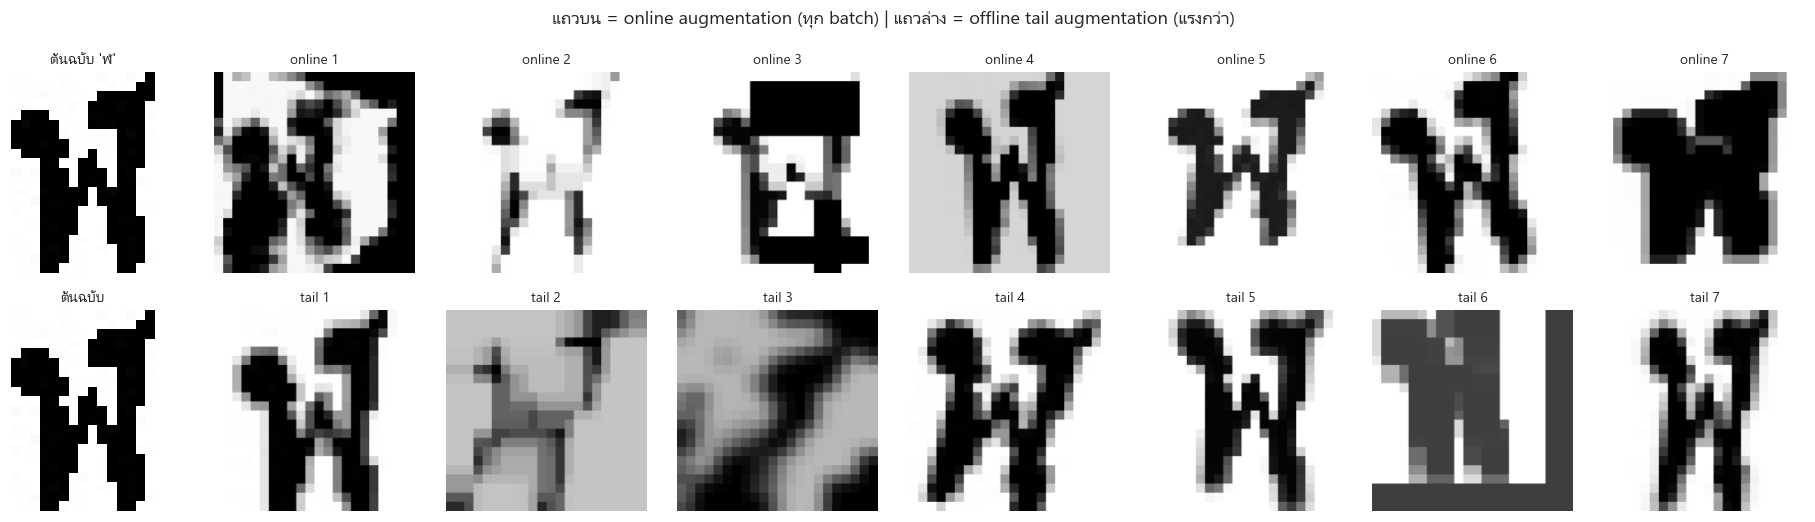

In [12]:
from src.transforms import build_train_transform, build_tail_transform, denormalize

sample_char = "ฬ"            # ลองเปลี่ยนเป็น 'ฃ' / 'ก' / 'ี' ดูด้วย
label = cm.char_to_label[sample_char]
src_file = list_images(RAW_DIR/str(cm.label_to_folder[label]))[0]
src_img = read_image(src_file)

tf_online = build_train_transform(cfg)
tf_tail   = build_tail_transform(cfg)

fig, axes = plt.subplots(2, 8, figsize=(17, 4.8))
axes[0,0].imshow(src_img); axes[0,0].set_title(f"ต้นฉบับ '{sample_char}'", fontsize=10)
axes[1,0].imshow(src_img); axes[1,0].set_title("ต้นฉบับ", fontsize=10)
for i in range(1, 8):
    axes[0,i].imshow(denormalize(tf_online(image=src_img)["image"]).permute(1,2,0).numpy())
    axes[0,i].set_title(f"online {i}", fontsize=9)
    axes[1,i].imshow(tf_tail(image=src_img)["image"])
    axes[1,i].set_title(f"tail {i}", fontsize=9)
for a in axes.ravel(): a.axis("off")
fig.suptitle("แถวบน = online augmentation (ทุก batch) | แถวล่าง = offline tail augmentation (แรงกว่า)",
             fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR/"eda_05_augmentation.png", dpi=150); plt.show()

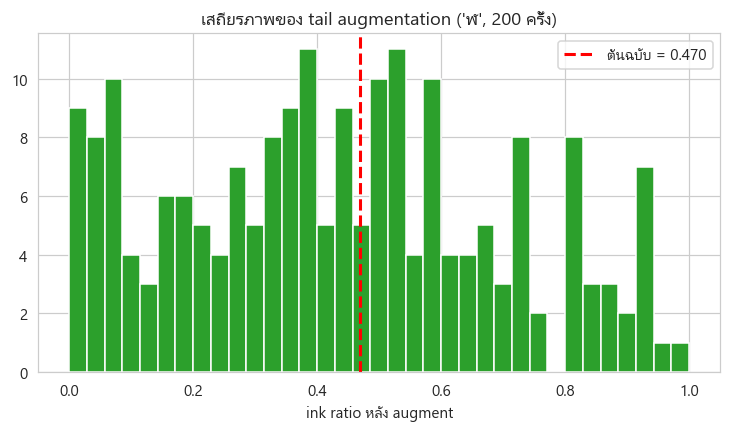

ภาพที่เกือบว่าง (ink < 20% ของเดิม): 28/200


In [13]:
from src.transforms import AutoInvert
invert = AutoInvert()
base_img = invert(image=src_img)["image"]

# ตรวจว่า tail augmentation ไม่ทำให้ตัวอักษรหายไป (ink ratio ไม่ควรตกจากเดิมมาก)
orig_g = cv2.cvtColor(src_img, cv2.COLOR_RGB2GRAY)
orig_ink = (orig_g < 128).mean()
inks = []
for _ in range(200):
    a = tf_tail(image=src_img)["image"]
    inks.append((cv2.cvtColor(a, cv2.COLOR_RGB2GRAY) < 128).mean())
inks = np.array(inks)

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(inks, bins=35, color="#2ca02c", edgecolor="white")
ax.axvline(orig_ink, c="red", ls="--", lw=2, label=f"ต้นฉบับ = {orig_ink:.3f}")
ax.set_xlabel("ink ratio หลัง augment"); ax.set_title(
    f"เสถียรภาพของ tail augmentation ('{sample_char}', 200 ครั้ง)")
ax.legend(); plt.show()
print(f"ภาพที่เกือบว่าง (ink < 20% ของเดิม): {(inks < orig_ink*0.2).sum()}/200")

## 6. ตรวจสุขภาพของ Split
รันหลัง `python -m src.make_splits` แล้วเท่านั้น
ข้อที่ต้องผ่านทั้งหมด:
- `origin_id` ไม่ซ้ำข้าม train/val
- `val.csv` มี `is_augmented == 0` ทุกแถว
- ทุกคลาสมีข้อมูลใน val อย่างน้อย 1 ภาพ

In [14]:
train_csv = Path(cfg.get_path("paths.train_csv"))
val_csv   = Path(cfg.get_path("paths.val_csv"))

if not train_csv.exists():
    print("ยังไม่ได้รัน make_splits — ข้ามส่วนนี้ก่อน")
else:
    tr, va = pd.read_csv(train_csv), pd.read_csv(val_csv)
    ov_origin = set(tr["origin_id"]) & set(va["origin_id"])
    ov_path   = set(tr["filepath"])  & set(va["filepath"])

    print(f"train {len(tr):,} ({len(tr)/(len(tr)+len(va))*100:.1f}%) | "
          f"val {len(va):,} ({len(va)/(len(tr)+len(va))*100:.1f}%)")
    print(f"{'✅' if not ov_path   else '❌'} filepath ซ้ำข้าม split : {len(ov_path)}")
    print(f"{'✅' if not ov_origin else '⚠️ '} origin_id ซ้ำข้าม split: {len(ov_origin)}"
          f"{'  ← คลาส singleton ตามนโยบาย' if ov_origin else ''}")
    print(f"{'✅' if (va['is_augmented']==0).all() else '❌'} val เป็นภาพต้นฉบับล้วน")

    tc = np.bincount(tr["label"], minlength=cm.num_classes)
    vc = np.bincount(va["label"], minlength=cm.num_classes)
    print(f"{'✅' if (vc>0).all() else '❌'} ทุกคลาสมีข้อมูลใน val "
          f"(ขาด {int((vc==0).sum())} คลาส)")
    print(f"{'✅' if (tc>0).all() else '⚠️ '} ทุกคลาสมีข้อมูลใน train "
          f"(ขาด {int((tc==0).sum())} คลาส → รอ offline augment)")

    split_df = pd.DataFrame({"class": cm.class_names, "raw": counts,
                             "train": tc, "val": vc,
                             "aug": [int(((tr.label==i)&(tr.is_augmented==1)).sum())
                                     for i in range(cm.num_classes)]})
    display(split_df.sort_values("train").head(20))
    split_df.to_csv(FIG_DIR/"eda_split_summary.csv", index=False, encoding="utf-8-sig")

train 54,482 (81.3%) | val 12,547 (18.7%)
✅ filepath ซ้ำข้าม split : 0
⚠️  origin_id ซ้ำข้าม split: 2  ← คลาส singleton ตามนโยบาย
✅ val เป็นภาพต้นฉบับล้วน
✅ ทุกคลาสมีข้อมูลใน val (ขาด 0 คลาส)
✅ ทุกคลาสมีข้อมูลใน train (ขาด 0 คลาส → รอ offline augment)


,class,raw,train,val,aug
62,๐,83,66,17,0
34,ศ,94,75,19,0
26,ฟ,103,82,21,0
9,ญ,113,90,23,0
11,ฐ,118,94,24,0
57,็,119,95,24,0
56,ๆ,121,97,24,0
49,ู,139,111,28,0
45,ี,143,114,29,0
19,ธ,143,114,29,0


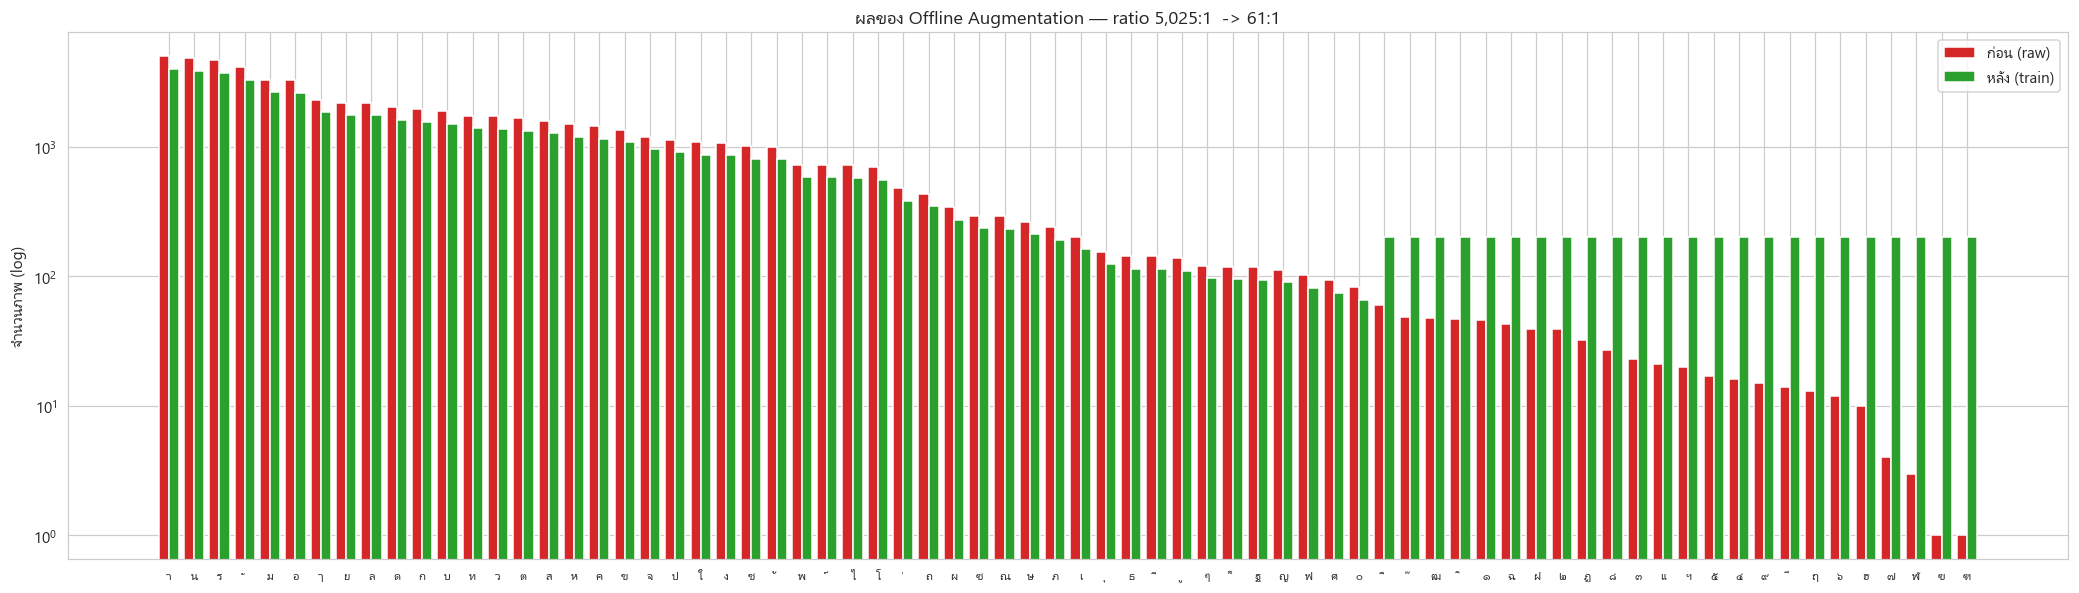

In [18]:
# เปรียบเทียบการกระจายก่อน/หลัง offline augmentation
if train_csv.exists() and split_df["aug"].sum() > 0:
    d = split_df.sort_values("raw", ascending=False)
    x = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(19, 5.5))
    ax.bar(x-0.2, d["raw"],   width=0.4, label="ก่อน (raw)",  color="#d62728")
    ax.bar(x+0.2, d["train"], width=0.4, label="หลัง (train)", color="#2ca02c")
    ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(d["class"], fontsize=8)
    ax.set_ylabel("จำนวนภาพ (log)"); ax.legend()
    ax.set_title(f"ผลของ Offline Augmentation — ratio {counts.max()/max(counts.min(),1):,.0f}:1 "
                 f" -> {d['train'].max()/max(d['train'].min(),1):,.0f}:1")
    fig.tight_layout(); fig.savefig(FIG_DIR/"eda_06_before_after_aug.png", dpi=150); plt.show()
else:
    print("ยังไม่ได้รัน offline_augment — ข้าม")

## 7. สรุปสำหรับสไลด์

In [16]:
summary = f"""
{'='*66}
DATASET SUMMARY — Thai Character Recognition
{'='*66}
  คลาส              : {cm.num_classes}
  ภาพทั้งหมด        : {total:,}
  เฉลี่ย / มัธยฐาน  : {total/cm.num_classes:,.0f} / {np.median(counts):,.0f}
  มากสุด            : {stats.iloc[0]['class']} = {stats.iloc[0]['count']:,}
  น้อยสุด           : {stats.iloc[-1]['class']} = {stats.iloc[-1]['count']:,}
  Imbalance ratio   : {counts.max()/max(counts.min(),1):,.0f} : 1
  Gini coefficient  : {gini:.3f}

  คลาส < 20 ภาพ     : {int((counts<20).sum())}
  คลาส < 50 ภาพ     : {int((counts<50).sum())}  (รวม {int(counts[counts<50].sum()):,} ภาพ = {counts[counts<50].sum()/total*100:.2f}%)
  คลาส >= 200 ภาพ   : {int((counts>=200).sum())}  (รวม {int(counts[counts>=200].sum()):,} ภาพ = {counts[counts>=200].sum()/total*100:.1f}%)

  ความท้าทายหลัก
   1. Extreme long-tail  → ใช้ Macro-F1 เป็นตัวตัดสิน ไม่ใช่ Accuracy
   2. Visual similarity  → {len(sim_df)} คู่มี cosine similarity > {sim_df['similarity'].min():.2f}
   3. Aspect ratio หลากหลาย ({props['aspect'].min():.2f}–{props['aspect'].max():.2f}) → ต้อง Pad-to-Square
   4. Polarity ไม่สม่ำเสมอ ({props['dark_bg'].mean()*100:.1f}% พื้นหลังดำ) → ต้อง AutoInvert
{'='*66}
"""
print(summary)
Path(FIG_DIR/"eda_summary.txt").write_text(summary, encoding="utf-8")
stats.to_csv(FIG_DIR/"eda_class_stats.csv", index=False, encoding="utf-8-sig")
print(f"✓ บันทึกทุกอย่างที่ {FIG_DIR}")
print("ขั้นถัดไป: python -m src.make_splits --ratio 0.8")


DATASET SUMMARY — Thai Character Recognition
  คลาส              : 72
  ภาพทั้งหมด        : 62,707
  เฉลี่ย / มัธยฐาน  : 871 / 221
  มากสุด            : า = 5,025
  น้อยสุด           : ฑ = 1
  Imbalance ratio   : 5,025 : 1
  Gini coefficient  : 0.672

  คลาส < 20 ภาพ     : 11
  คลาส < 50 ภาพ     : 23  (รวม 540 ภาพ = 0.86%)
  คลาส >= 200 ภาพ   : 37  (รวม 60,776 ภาพ = 96.9%)

  ความท้าทายหลัก
   1. Extreme long-tail  → ใช้ Macro-F1 เป็นตัวตัดสิน ไม่ใช่ Accuracy
   2. Visual similarity  → 25 คู่มี cosine similarity > 0.84
   3. Aspect ratio หลากหลาย (0.28–2.33) → ต้อง Pad-to-Square
   4. Polarity ไม่สม่ำเสมอ (9.6% พื้นหลังดำ) → ต้อง AutoInvert

✓ บันทึกทุกอย่างที่ outputs\figures
ขั้นถัดไป: python -m src.make_splits --ratio 0.8
